
| Aspect | Full Notebook | This Demo |
|--------|--------------|-----------|
| Train rows | 1,296,675 | ~20,000 (stratified) |
| Test rows | 555,719 | ~10,000 (stratified) |
| Models | RF, XGB, LR, Stacking, Baseline | Same 5 models |
| SMOTE, CV, Tuning | Yes | Yes (lighter) |
| Spark | Full pipeline | Noted (skipped for speed) |
| Runtime | ~10+ min | **< 1 min** |

In [27]:
%pip install -q pandas numpy scikit-learn imbalanced-learn xgboost matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

import time
_t0 = time.time()
print("Libraries loaded.")

Note: you may need to restart the kernel to use updated packages.
Libraries loaded.


---
## 1. Data Loading — Stratified Sample
We sample ~20K train / ~10K test rows while preserving the fraud ratio (~0.58%).

In [28]:
# Load full datasets
df_train_full = pd.read_csv('../Real_Data_Fraud/fraudTrain.csv')
df_test_full  = pd.read_csv('../Real_Data_Fraud/fraudTest.csv')

print(f"Full train: {len(df_train_full):,} rows  |  Fraud rate: {df_train_full['is_fraud'].mean()*100:.2f}%")
print(f"Full test:  {len(df_test_full):,} rows   |  Fraud rate: {df_test_full['is_fraud'].mean()*100:.2f}%")

# Stratified sample — preserves fraud ratio exactly
from sklearn.model_selection import train_test_split

df_train, _ = train_test_split(df_train_full, train_size=20_000,
                                stratify=df_train_full['is_fraud'], random_state=42)
df_test, _  = train_test_split(df_test_full, train_size=10_000,
                                stratify=df_test_full['is_fraud'], random_state=42)

del df_train_full, df_test_full  # free memory

print(f"\nSampled train: {len(df_train):,} rows  |  Fraud rate: {df_train['is_fraud'].mean()*100:.2f}%")
print(f"Sampled test:  {len(df_test):,} rows   |  Fraud rate: {df_test['is_fraud'].mean()*100:.2f}%")

Full train: 1,296,675 rows  |  Fraud rate: 0.58%
Full test:  555,719 rows   |  Fraud rate: 0.39%

Sampled train: 20,000 rows  |  Fraud rate: 0.58%
Sampled test:  10,000 rows   |  Fraud rate: 0.39%


---
## 2. Initial Data Cleaning
Convert datetime columns and remove auto-generated index.

In [29]:
df_test['trans_date_trans_time']  = pd.to_datetime(df_test['trans_date_trans_time'], errors='coerce')
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'], errors='coerce')

for df in [df_test, df_train]:
    if 'Unnamed: 0' in df.columns:
        df.drop('Unnamed: 0', axis=1, inplace=True)

print(f"Train columns: {len(df_train.columns)}  |  Test columns: {len(df_test.columns)}")
print("Missing values (train):", df_train.isnull().sum().sum())
print("Missing values (test): ", df_test.isnull().sum().sum())

Train columns: 22  |  Test columns: 22
Missing values (train): 0
Missing values (test):  0


---
## 3. Exploratory Data Analysis (EDA)
### 3.1 Numerical Distributions

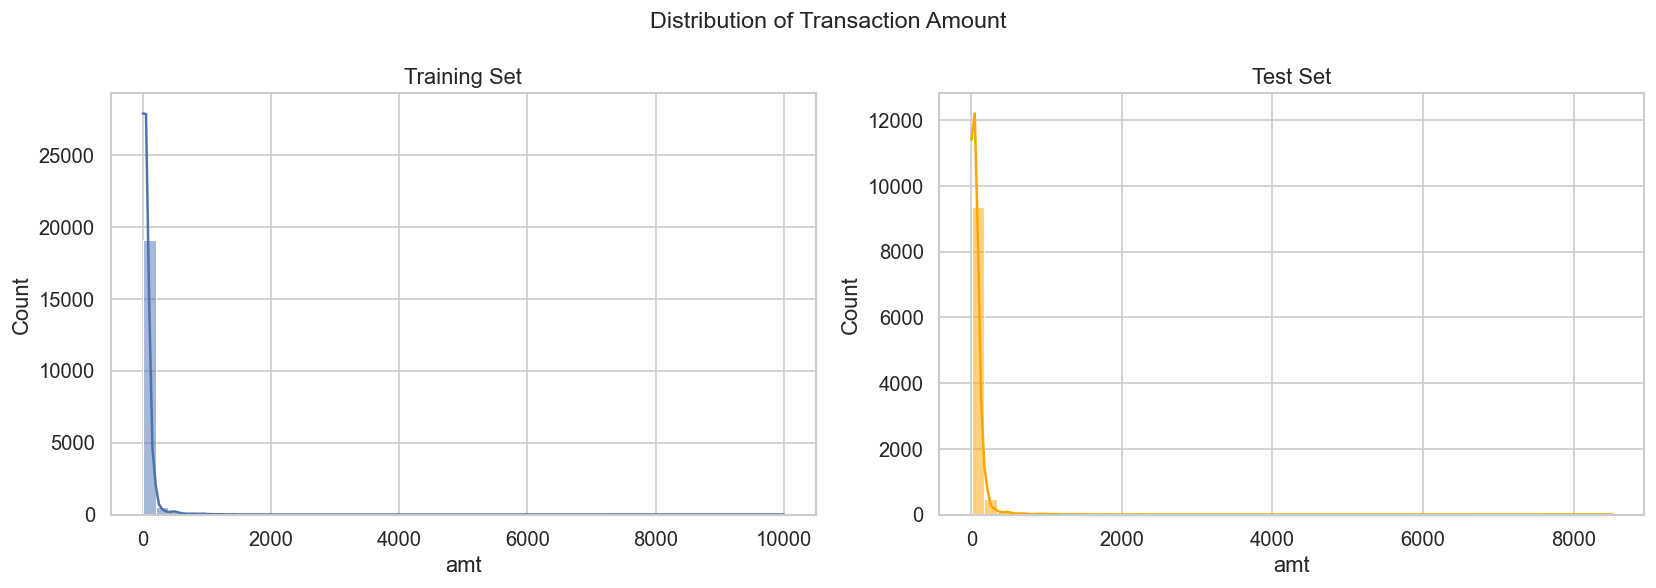

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Transaction Amount', fontsize=14)

sns.histplot(df_train['amt'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Training Set')

sns.histplot(df_test['amt'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Test Set')

plt.tight_layout()
plt.show()

### 3.2 Fraud Class Imbalance

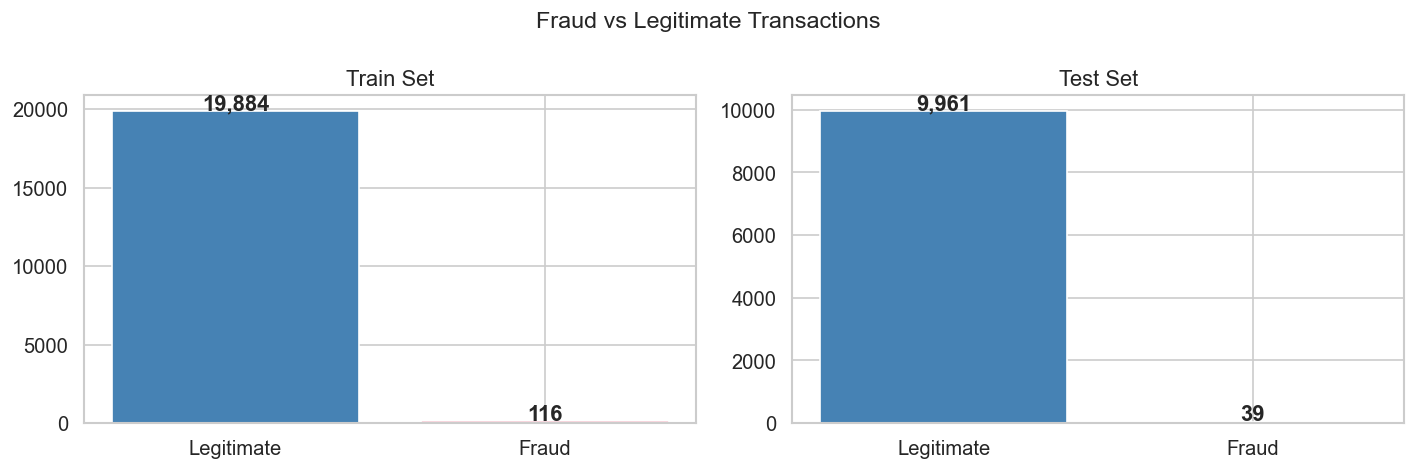

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fraud vs Legitimate Transactions', fontsize=14)

for ax, (name, df) in zip(axes, [('Train', df_train), ('Test', df_test)]):
    counts = df['is_fraud'].value_counts()
    ax.bar(['Legitimate', 'Fraud'], counts.values, color=['steelblue', 'crimson'])
    ax.set_title(f'{name} Set')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.3 Fraud Rate by Category & Hour

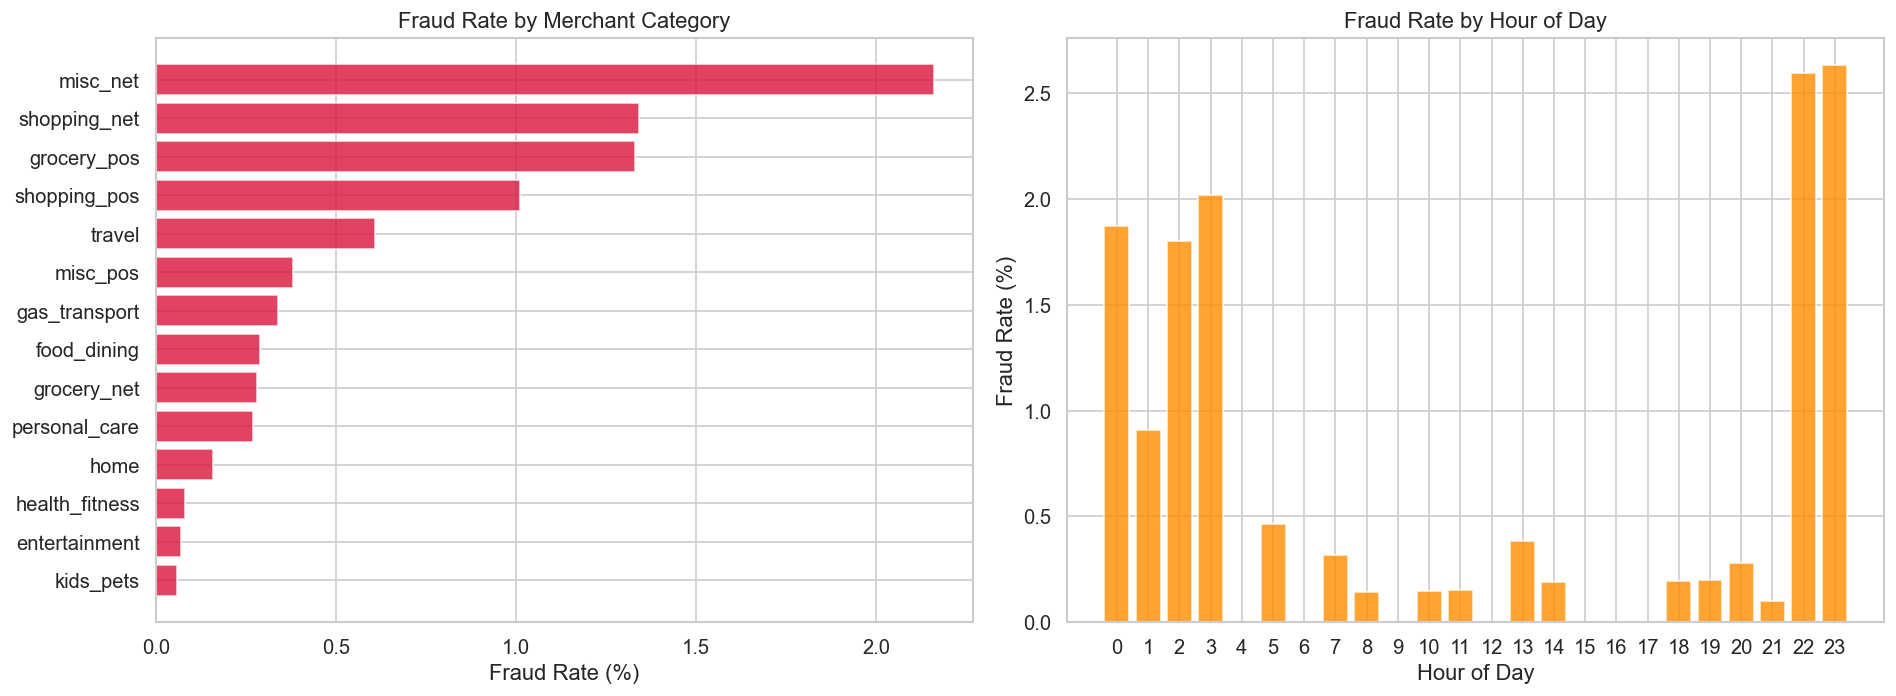

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud rate by category
fraud_rate = (df_train.groupby('category')['is_fraud']
              .agg(['sum', 'count'])
              .rename(columns={'sum': 'fraud', 'count': 'total'}))
fraud_rate['rate'] = (fraud_rate['fraud'] / fraud_rate['total'] * 100).round(2)
fraud_rate = fraud_rate.sort_values('rate', ascending=True)

axes[0].barh(fraud_rate.index, fraud_rate['rate'], color='crimson', alpha=0.8)
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Merchant Category')

# Fraud by hour
df_train['hour_temp'] = df_train['trans_date_trans_time'].dt.hour
hourly = df_train.groupby('hour_temp')['is_fraud'].agg(['sum', 'count'])
hourly['rate'] = (hourly['sum'] / hourly['count'] * 100).round(3)

axes[1].bar(hourly.index, hourly['rate'], color='darkorange', alpha=0.8)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_xticks(range(0, 24))

df_train.drop('hour_temp', axis=1, inplace=True, errors='ignore')
plt.tight_layout()
plt.show()

### 3.4 Transaction Amount by Fraud Status

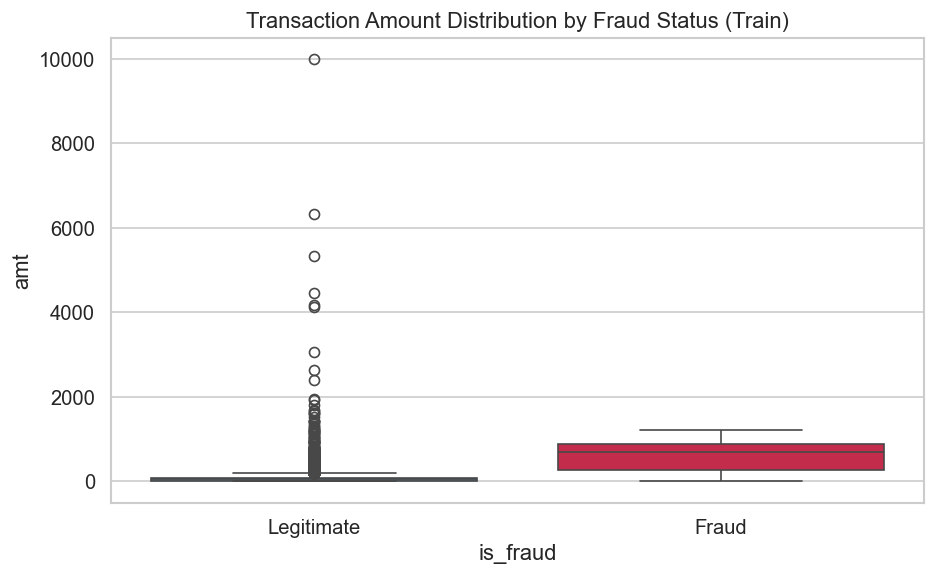

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='is_fraud', y='amt', data=df_train, ax=ax, palette=['steelblue', 'crimson'])
ax.set_xticklabels(['Legitimate', 'Fraud'])
ax.set_title('Transaction Amount Distribution by Fraud Status (Train)')
plt.tight_layout()
plt.show()

### 3.5 Correlation Heatmap

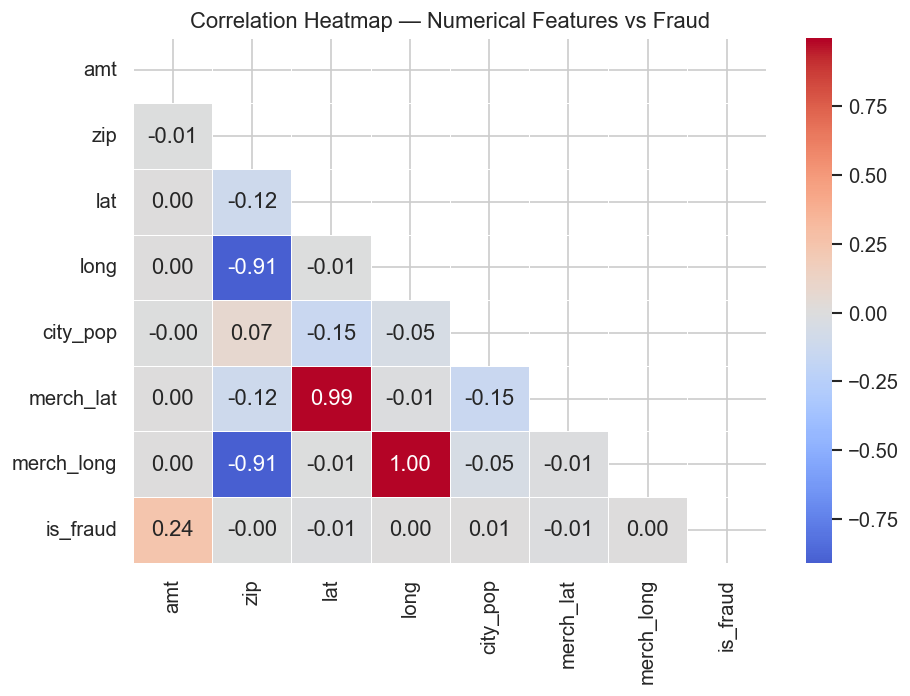

In [34]:
numerical_cols = ['amt', 'zip', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud']
corr_matrix = df_train[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Numerical Features vs Fraud')
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering & Preprocessing
Create 5 new features: `customer_age`, `distance_km`, `hour_of_day`, `trans_count_24h`, `trans_amt_24h`

In [35]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2) * np.sin(dlambda/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def engineer_new_features(df):
    df = df.copy()
    df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

    df['customer_age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year
    df['distance_km'] = calculate_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])
    df['hour_of_day'] = df['trans_date_trans_time'].dt.hour

    df = df.sort_values(by=['cc_num', 'trans_date_trans_time'])
    df.set_index('trans_date_trans_time', inplace=True)
    df['trans_count_24h'] = df.groupby('cc_num')['amt'].transform(lambda x: x.rolling('24h').count())
    df['trans_amt_24h']   = df.groupby('cc_num')['amt'].transform(lambda x: x.rolling('24h').sum())
    df.reset_index(inplace=True)
    return df

print("Engineering features...")
df_train = engineer_new_features(df_train)
df_test  = engineer_new_features(df_test)
print("New features:", ['customer_age', 'distance_km', 'hour_of_day', 'trans_count_24h', 'trans_amt_24h'])

Engineering features...
New features: ['customer_age', 'distance_km', 'hour_of_day', 'trans_count_24h', 'trans_amt_24h']


In [36]:
# Save gender for fairness check later
gender_test_series  = df_test['gender'].copy()
gender_train_series = df_train['gender'].copy()

# Drop identifier and redundant columns
cols_to_drop = ['trans_date_trans_time', 'dob', 'lat', 'long', 'merch_lat', 'merch_long',
                'trans_num', 'unix_time', 'first', 'last', 'street', 'city', 'state',
                'zip', 'cc_num', 'gender']

df_train = df_train.drop(columns=cols_to_drop, errors='ignore')
df_test  = df_test.drop(columns=cols_to_drop, errors='ignore')

# Encode categorical variables
cat_cols = ['merchant', 'category', 'job']
for col in cat_cols:
    le = LabelEncoder()
    all_values = pd.concat([df_train[col], df_test[col]], axis=0).astype(str)
    le.fit(all_values)
    df_train[col] = le.transform(df_train[col].astype(str))
    df_test[col]  = le.transform(df_test[col].astype(str))

print("Columns for modeling:", df_train.columns.tolist())

Columns for modeling: ['merchant', 'category', 'amt', 'city_pop', 'job', 'is_fraud', 'customer_age', 'distance_km', 'hour_of_day', 'trans_count_24h', 'trans_amt_24h']


In [37]:
# Split features / target
X_train = df_train.drop('is_fraud', axis=1)
y_train = df_train['is_fraud']
X_test  = df_test.drop('is_fraud', axis=1)
y_test  = df_test['is_fraud']

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE — balance fraud to 10% of total
print(f"Before SMOTE — Fraud: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
smote = SMOTE(random_state=42, sampling_strategy=0.1)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"After  SMOTE — Fraud: {y_train_resampled.sum()} ({y_train_resampled.mean()*100:.2f}%)")

Before SMOTE — Fraud: 116 (0.58%)
After  SMOTE — Fraud: 1988 (9.09%)


### SMOTE Visualization

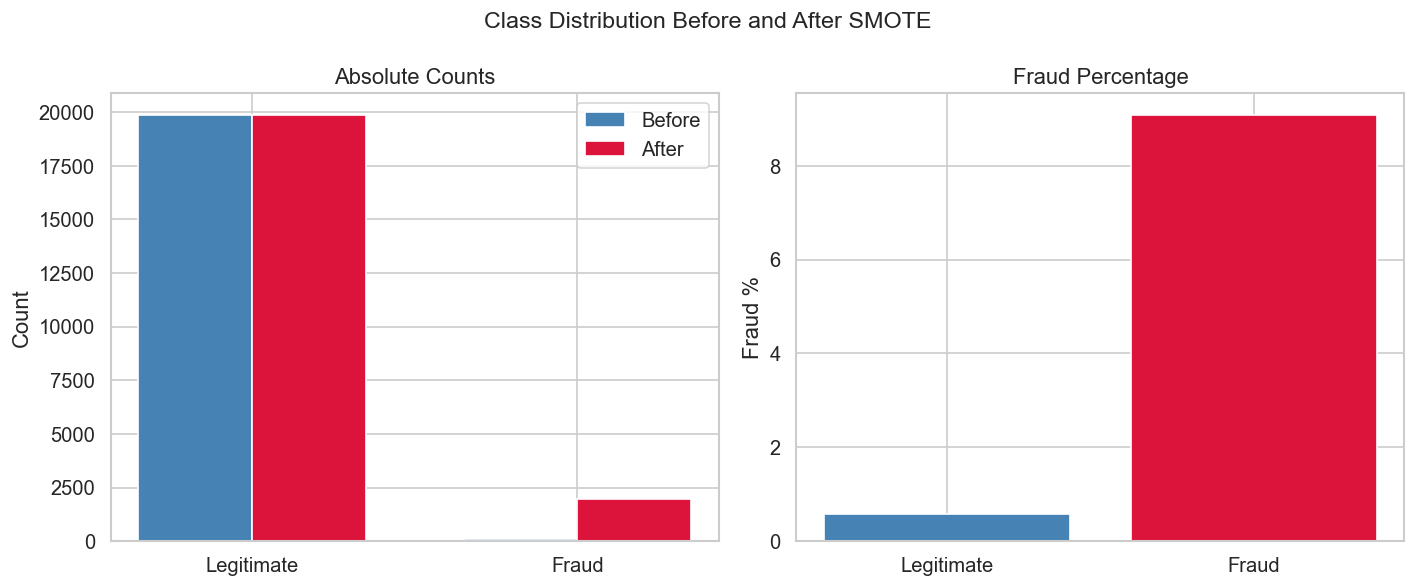

In [38]:
labels = ['Legitimate', 'Fraud']
before = [int((y_train == 0).sum()), int((y_train == 1).sum())]
after  = [int((y_train_resampled == 0).sum()), int((y_train_resampled == 1).sum())]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Distribution Before and After SMOTE', fontsize=14)

x = np.arange(len(labels))
w = 0.35
axes[0].bar(x - w/2, before, w, label='Before', color='steelblue')
axes[0].bar(x + w/2, after, w, label='After', color='crimson')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Count')
axes[0].set_title('Absolute Counts')
axes[0].legend()

axes[1].bar(labels, [before[1]/sum(before)*100, after[1]/sum(after)*100],
            color=['steelblue', 'crimson'])
axes[1].set_ylabel('Fraud %')
axes[1].set_title('Fraud Percentage')

plt.tight_layout()
plt.show()

---
## 5. Model Training & Evaluation
### 5.1 Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("Training Random Forest...")
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test_scaled)

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_rf):.4f}")

Training Random Forest...

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9961
           1       0.54      0.67      0.60        39

    accuracy                           1.00     10000
   macro avg       0.77      0.83      0.80     10000
weighted avg       1.00      1.00      1.00     10000

ROC-AUC Score: 0.8322


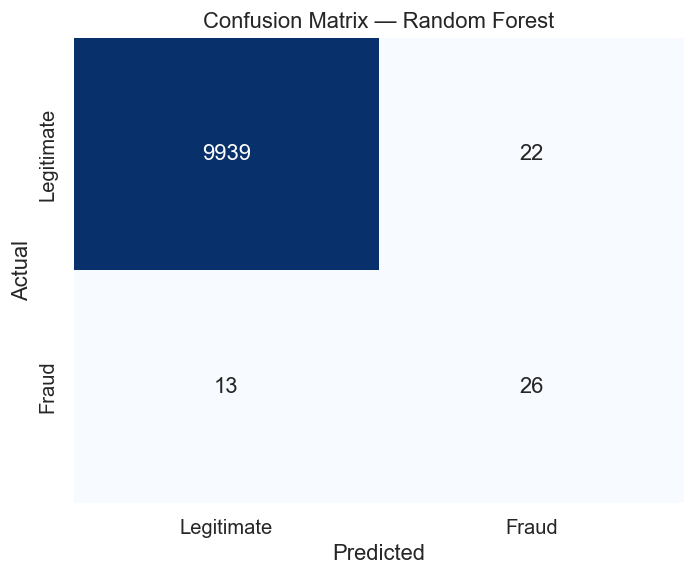

In [40]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Random Forest')
plt.xticks([0.5, 1.5], ['Legitimate', 'Fraud'])
plt.yticks([0.5, 1.5], ['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()

### 5.2 XGBoost

In [41]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=50, learning_rate=0.1, max_depth=6,
    random_state=42, n_jobs=-1, eval_metric='logloss'
)

print("Training XGBoost...")
xgb_model.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_xgb):.4f}")

Training XGBoost...

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9961
           1       0.51      0.67      0.58        39

    accuracy                           1.00     10000
   macro avg       0.75      0.83      0.79     10000
weighted avg       1.00      1.00      1.00     10000

ROC-AUC Score: 0.8321


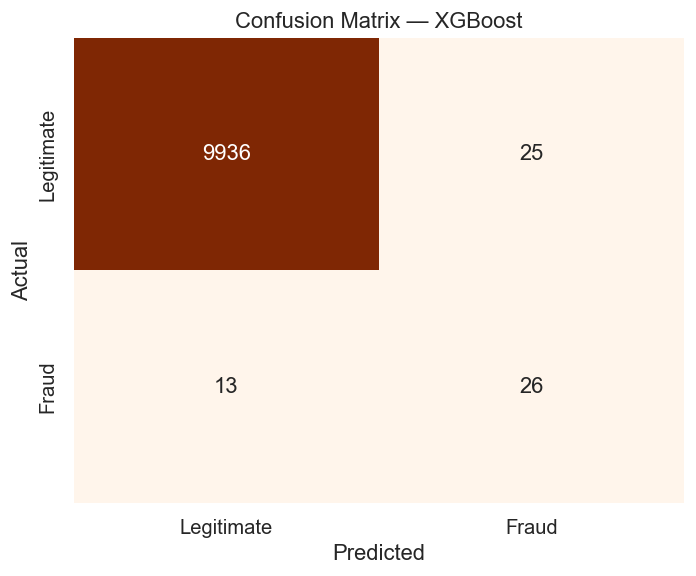

In [42]:
plt.figure(figsize=(6, 5))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — XGBoost')
plt.xticks([0.5, 1.5], ['Legitimate', 'Fraud'])
plt.yticks([0.5, 1.5], ['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()

### 5.3 Cross-Validation (3-Fold)

In [43]:
from sklearn.model_selection import cross_validate

scoring = ['recall', 'precision', 'f1', 'roc_auc']

print("Cross-validating Random Forest...")
cv_rf = cross_validate(rf_model, X_train_resampled, y_train_resampled,
                       cv=3, scoring=scoring, n_jobs=-1)
print("Cross-validating XGBoost...")
cv_xgb = cross_validate(xgb_model, X_train_resampled, y_train_resampled,
                        cv=3, scoring=scoring, n_jobs=-1)

for name, cv in [('Random Forest', cv_rf), ('XGBoost', cv_xgb)]:
    print(f"\n{name} CV Results:")
    for metric in scoring:
        scores = cv[f'test_{metric}']
        print(f"  {metric:>10s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Cross-validating Random Forest...
Cross-validating XGBoost...

Random Forest CV Results:
      recall: 0.9371 (+/- 0.0060)
   precision: 0.9816 (+/- 0.0062)
          f1: 0.9588 (+/- 0.0031)
     roc_auc: 0.9988 (+/- 0.0001)

XGBoost CV Results:
      recall: 0.9230 (+/- 0.0117)
   precision: 0.9740 (+/- 0.0072)
          f1: 0.9478 (+/- 0.0086)
     roc_auc: 0.9981 (+/- 0.0007)


### 5.4 Hyperparameter Tuning — RandomizedSearchCV

In [44]:
from sklearn.model_selection import RandomizedSearchCV

# RF tuning
rf_param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_dist, n_iter=4, cv=3, scoring='f1',
    n_jobs=-1, random_state=42, verbose=0
)

print("Tuning Random Forest...")
rf_search.fit(X_train_resampled, y_train_resampled)
best_rf_model = rf_search.best_estimator_
print(f"Best RF params: {rf_search.best_params_}")
print(f"Best RF F1:     {rf_search.best_score_:.4f}")

# XGBoost tuning
xgb_param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', verbosity=0),
    xgb_param_dist, n_iter=4, cv=3, scoring='f1',
    n_jobs=-1, random_state=42, verbose=0
)

print("\nTuning XGBoost...")
xgb_search.fit(X_train_resampled, y_train_resampled)
best_xgb_model = xgb_search.best_estimator_
print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best XGB F1:     {xgb_search.best_score_:.4f}")

Tuning Random Forest...
Best RF params: {'n_estimators': 50, 'min_samples_split': 2, 'max_depth': None}
Best RF F1:     0.9588

Tuning XGBoost...
Best XGB params: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}
Best XGB F1:     0.9622


---
## 6. Model Comparison — All Models Side-by-Side

In [45]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import recall_score, precision_score, f1_score

# Train remaining models
lr_model = LogisticRegression(random_state=42, max_iter=1000)
baseline = DummyClassifier(strategy='most_frequent', random_state=42)

base_estimators = [('rf', rf_model), ('xgb', xgb_model)]
stacking_model = StackingClassifier(estimators=base_estimators,
                                     final_estimator=LogisticRegression(random_state=42, max_iter=1000),
                                     cv=3, n_jobs=-1)

print("Training Logistic Regression...")
lr_model.fit(X_train_resampled, y_train_resampled)
print("Training Stacking Ensemble...")
stacking_model.fit(X_train_resampled, y_train_resampled)
print("Training Baseline...")
baseline.fit(X_train_resampled, y_train_resampled)

models = {
    "Baseline (Majority)": baseline,
    "Logistic Regression": lr_model,
    "Random Forest":       rf_model,
    "Tuned RF":            best_rf_model,
    "XGBoost":             xgb_model,
    "Tuned XGBoost":       best_xgb_model,
    "Stacking Ensemble":   stacking_model,
}

# Store probabilities for later use
model_probs = {}
results_list = []
print("\nEvaluating all models...")
print("=" * 65)
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    model_probs[name] = y_prob
    results_list.append({
        "Model":     name,
        "Recall":    recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred),
        "AUC-ROC":   roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results_list)
print(results_df.sort_values("Recall", ascending=False).to_string(index=False))

Training Logistic Regression...
Training Stacking Ensemble...
Training Baseline...

Evaluating all models...
              Model   Recall  Precision  F1-Score  AUC-ROC
  Stacking Ensemble 0.717949   0.509091  0.595745 0.961056
      Random Forest 0.666667   0.541667  0.597701 0.937528
           Tuned RF 0.666667   0.541667  0.597701 0.937528
            XGBoost 0.666667   0.509804  0.577778 0.964932
      Tuned XGBoost 0.666667   0.577778  0.619048 0.955202
Logistic Regression 0.410256   0.188235  0.258065 0.884962
Baseline (Majority) 0.000000   0.000000  0.000000 0.500000


### 6.1 Grouped Bar Chart — All Metrics

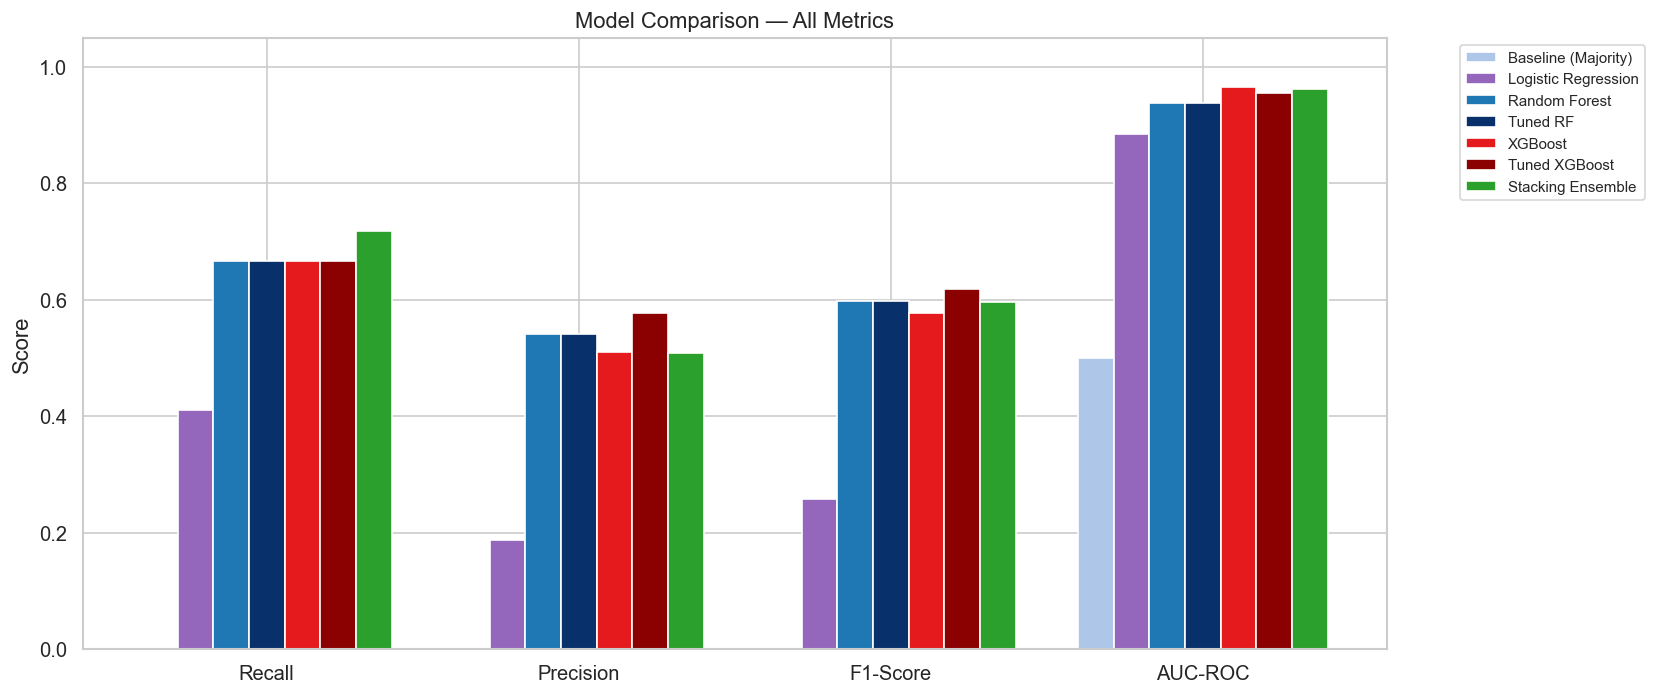

In [46]:
metric_names = ['Recall', 'Precision', 'F1-Score', 'AUC-ROC']
model_names  = list(models.keys())

colors_map = {
    'Baseline (Majority)': '#aec7e8', 'Logistic Regression': '#9467bd',
    'Random Forest': '#1f77b4', 'Tuned RF': '#08306b',
    'XGBoost': '#e41a1c', 'Tuned XGBoost': '#8b0000',
    'Stacking Ensemble': '#2ca02c',
}

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(metric_names))
n = len(model_names)
w = 0.8 / n

for i, name in enumerate(model_names):
    y_pred = models[name].predict(X_test_scaled)
    y_prob = model_probs[name]
    vals = [recall_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
            f1_score(y_test, y_pred), roc_auc_score(y_test, y_prob)]
    ax.bar(x + i*w - (n-1)*w/2, vals, w, label=name, color=colors_map.get(name, 'gray'))

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### 6.2 Precision-Recall & ROC Curves

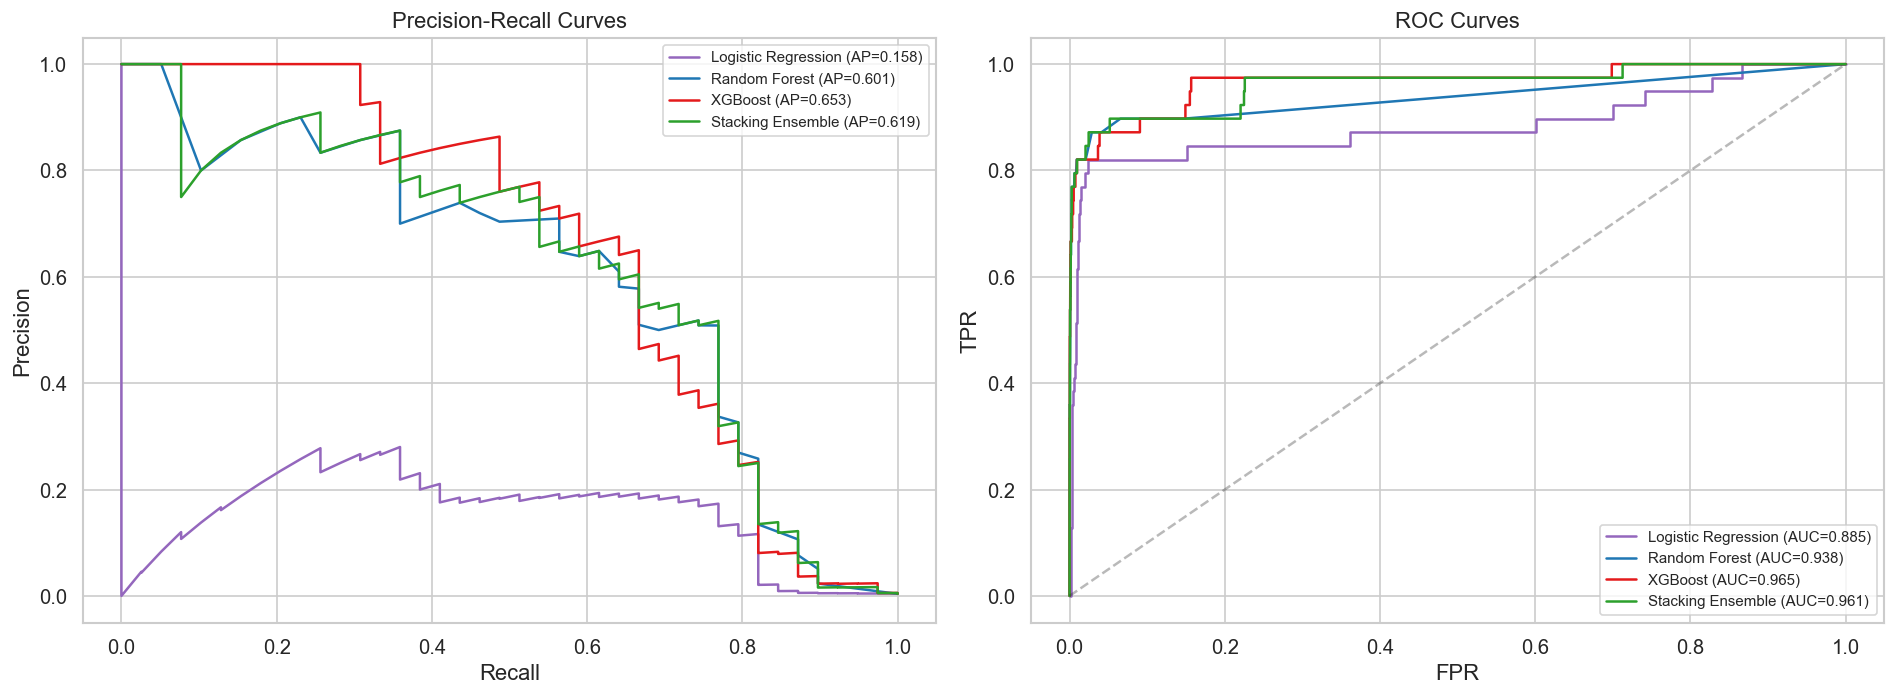

In [47]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'Baseline (Majority)': '#aec7e8', 'Logistic Regression': '#9467bd',
          'Random Forest': '#1f77b4', 'XGBoost': '#e41a1c', 'Stacking Ensemble': '#2ca02c'}

for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'Stacking Ensemble']:
    y_prob = model_probs[name]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[0].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=colors.get(name, 'gray'))

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors.get(name, 'gray'))

axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves')
axes[0].legend(fontsize=9)

axes[1].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 6.3 Feature Importance & Confusion Matrices

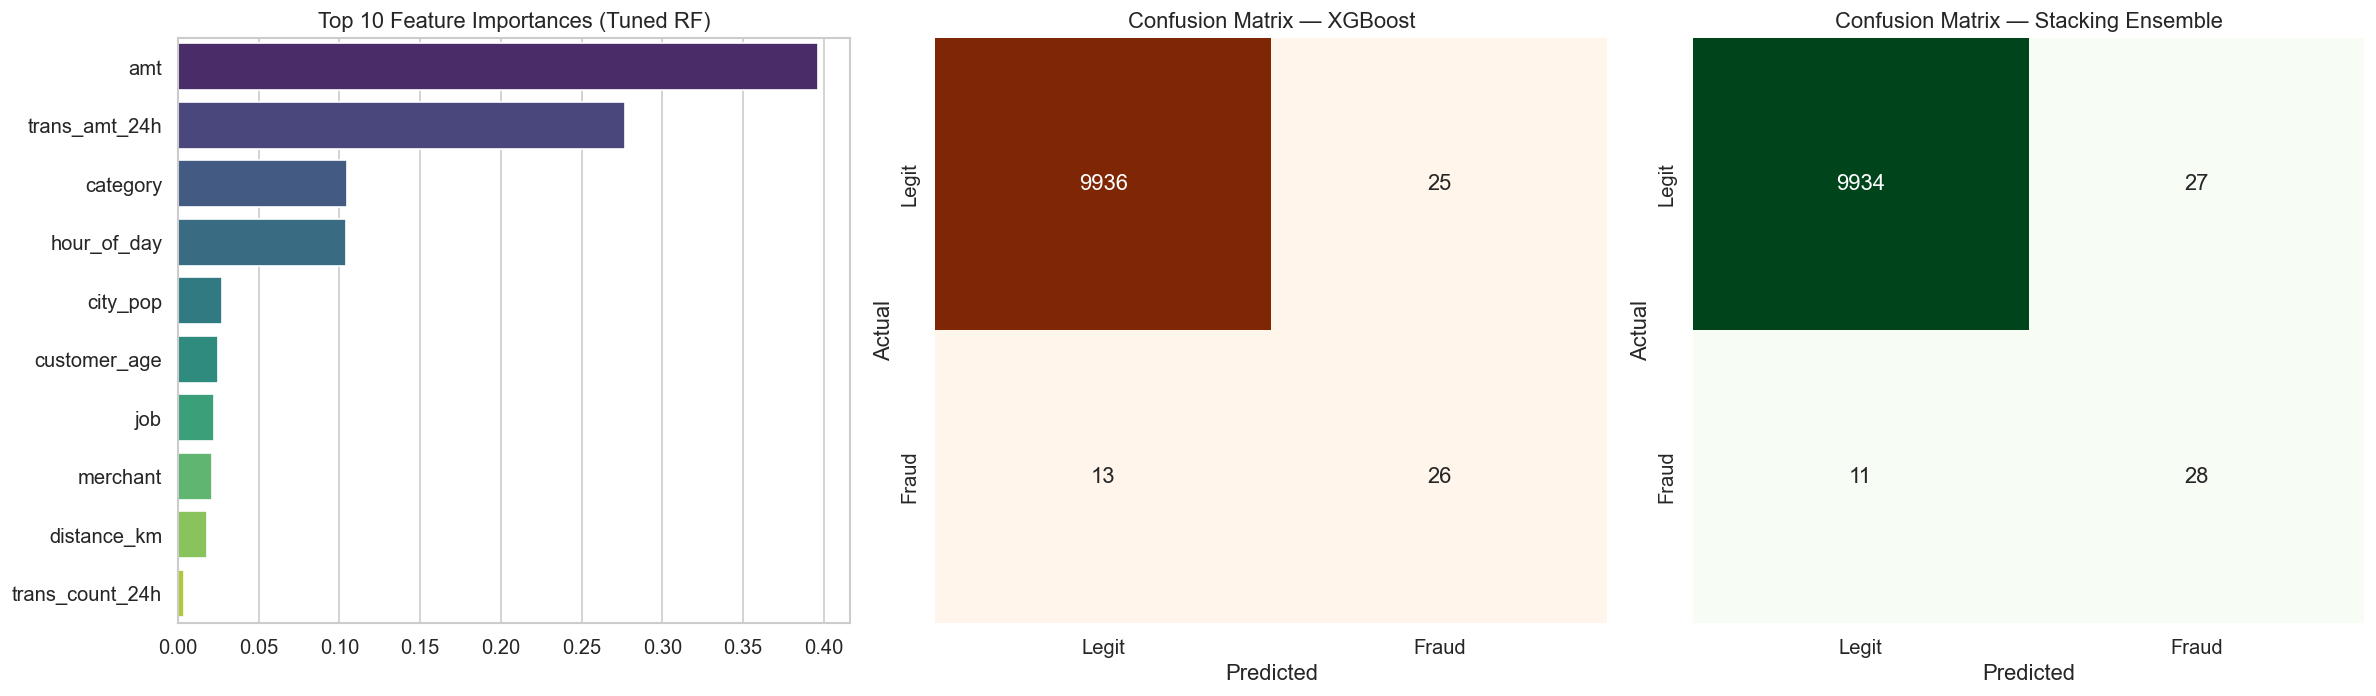

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Feature importance
feature_names = X_train.columns.tolist()
importances = best_rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

sns.barplot(x=importances[indices[:10]],
            y=[feature_names[i] for i in indices[:10]],
            ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Feature Importances (Tuned RF)')

# Confusion matrices
for ax, (name, cmap) in zip(axes[1:], [('XGBoost', 'Oranges'), ('Stacking Ensemble', 'Greens')]):
    y_pred = models[name].predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xticklabels(['Legit', 'Fraud'])
    ax.set_yticklabels(['Legit', 'Fraud'])

plt.tight_layout()
plt.show()

### 6.4 Decision Threshold Analysis

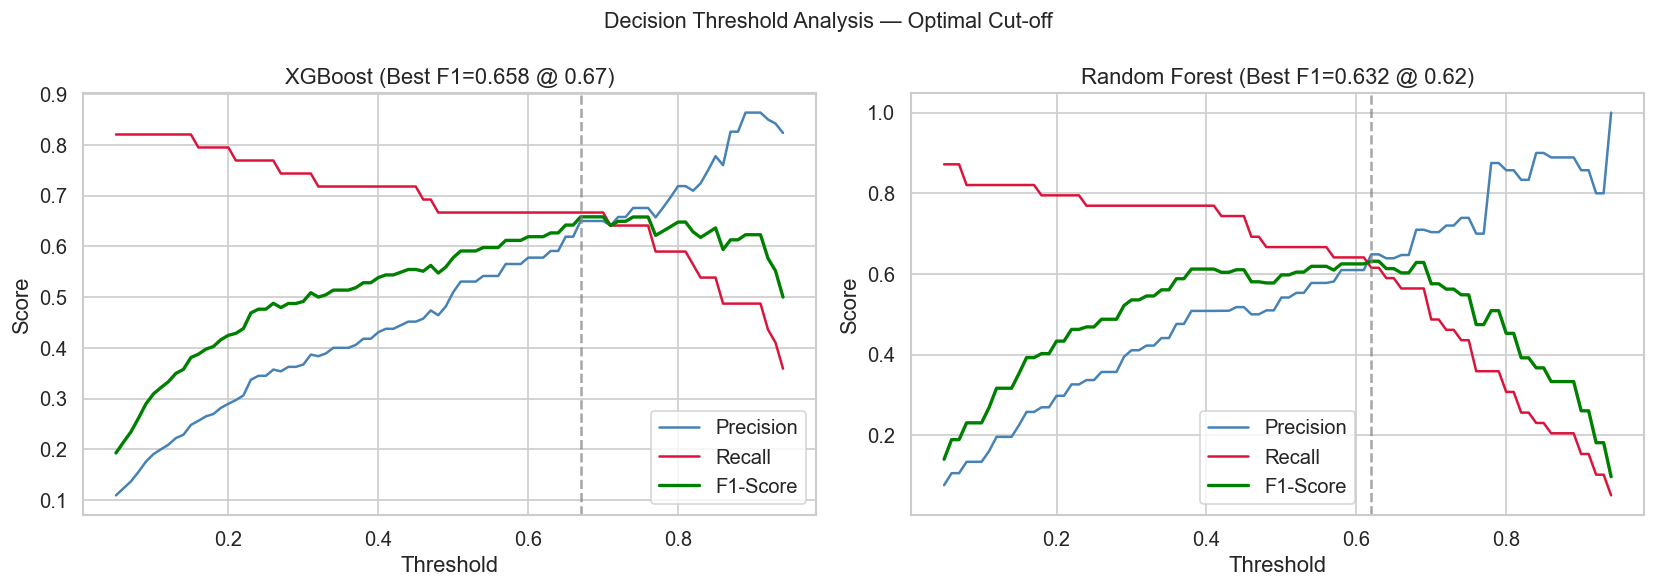

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Decision Threshold Analysis — Optimal Cut-off', fontsize=13)

for ax, model_name in zip(axes, ['XGBoost', 'Random Forest']):
    y_prob = model_probs[model_name]
    thresholds = np.arange(0.05, 0.95, 0.01)
    precisions = [precision_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
    recalls    = [recall_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]
    f1s        = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]

    ax.plot(thresholds, precisions, label='Precision', color='steelblue')
    ax.plot(thresholds, recalls, label='Recall', color='crimson')
    ax.plot(thresholds, f1s, label='F1-Score', color='green', linewidth=2)

    best_idx = np.argmax(f1s)
    ax.axvline(thresholds[best_idx], color='gray', linestyle='--', alpha=0.7)
    ax.set_title(f'{model_name} (Best F1={f1s[best_idx]:.3f} @ {thresholds[best_idx]:.2f})')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.legend()

plt.tight_layout()
plt.show()

### 6.5 Business Cost Analysis

In [55]:
# Adjustable operational inputs for demo discussion
avg_fraud_value = 100
investigation_cost = 10
decision_threshold = 0.8
transactions_per_day = 100_000
analyst_reviews_per_hour = 60

print("=" * 75)
print("BUSINESS COST & OPERATIONS CHECK")
print(f"Avg fraud loss per missed case : ${avg_fraud_value}")
print(f"Investigation cost per alert   : ${investigation_cost}")
print(f"Decision threshold             : {decision_threshold:.2f}")
print(f"Projected daily transactions   : {transactions_per_day:,}")
print(f"Analyst review speed           : {analyst_reviews_per_hour} alerts/hour")
print("=" * 75)

ops_rows = []

for name, model in models.items():
    y_prob = model_probs[name]
    y_pred = (y_prob >= decision_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    missed_fraud_cost = fn * avg_fraud_value
    false_alarm_cost  = fp * investigation_cost
    total_cost = missed_fraud_cost + false_alarm_cost

    alert_rate = y_pred.mean()
    projected_daily_alerts = int(round(alert_rate * transactions_per_day))
    analyst_hours_per_day = projected_daily_alerts / analyst_reviews_per_hour

    ops_rows.append({
        'Model': name,
        'Threshold': decision_threshold,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'Total Cost': total_cost,
        'Daily Alerts': projected_daily_alerts,
        'Analyst Hours/Day': analyst_hours_per_day,
    })

ops_df = pd.DataFrame(ops_rows).sort_values(['Total Cost', 'Daily Alerts'])
print(ops_df.to_string(index=False, formatters={
    'Threshold': '{:.2f}'.format,
    'Total Cost': '${:,.0f}'.format,
    'Analyst Hours/Day': '{:.1f}'.format,
}))

best_model = ops_df.iloc[0]
print("\nLowest-cost operating point under current assumptions:")
print(f"  {best_model['Model']} at threshold {best_model['Threshold']:.2f}")
print(f"  Total test-set cost : ${best_model['Total Cost']:,.0f}")
print(f"  Projected alerts/day: {int(best_model['Daily Alerts']):,}")
print(f"  Analyst hours/day   : {best_model['Analyst Hours/Day']:.1f}")

BUSINESS COST & OPERATIONS CHECK
Avg fraud loss per missed case : $100
Investigation cost per alert   : $10
Decision threshold             : 0.80
Projected daily transactions   : 100,000
Analyst review speed           : 60 alerts/hour
              Model Threshold  TP  FP  FN Total Cost  Daily Alerts Analyst Hours/Day
      Tuned XGBoost      0.80  24   7  15     $1,570           310               5.2
  Stacking Ensemble      0.80  25  17  14     $1,570           420               7.0
            XGBoost      0.80  23   9  16     $1,690           320               5.3
      Random Forest      0.80  14   2  25     $2,520           160               2.7
           Tuned RF      0.80  14   2  25     $2,520           160               2.7
Logistic Regression      0.80  14  45  25     $2,950           590               9.8
Baseline (Majority)      0.80   0   0  39     $3,900             0               0.0

Lowest-cost operating point under current assumptions:
  Tuned XGBoost at threshold 

---
## 7. Big Data Scalability — Apache Spark (Reference)

> **Note:** The Spark pipeline is demonstrated in the full notebook (`Fraud_Detection_Clean.ipynb`).
> Starting a JVM + Spark session alone takes ~15-20s, which would exceed our 1-minute budget.
>
> The full Spark pipeline:
> 1. Loads all 1.3M rows into a Spark DataFrame
> 2. Encodes categoricals with `StringIndexer`
> 3. Assembles features with `VectorAssembler` + `StandardScaler`
> 4. Trains a `RandomForestClassifier` (100 trees)
> 5. Evaluates AUC-ROC and saves the pipeline model
>
> This demonstrates the same fraud detection logic scales to distributed clusters via PySpark.

---
## 8. Fairness Check — Error Rates by Gender

In [51]:
y_pred_best = best_rf_model.predict(X_test_scaled)

gender_test = gender_test_series.reset_index(drop=True).map({'F': 'Female', 'M': 'Male'})

fairness_df = pd.DataFrame({
    'gender': gender_test.values,
    'y_true': y_test.values,
    'y_pred': y_pred_best
})

print("Fairness Check — Error Rates by Gender")
print("=" * 50)

for g in ['Female', 'Male']:
    subset = fairness_df[fairness_df['gender'] == g]
    cm = confusion_matrix(subset['y_true'], subset['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) * 100
    fnr = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0
    print(f"\n{g}:")
    print(f"  False Positive Rate: {fpr:.2f}%")
    print(f"  False Negative Rate: {fnr:.2f}%")

print("\nSimilar FPR/FNR across genders indicates no systematic gender bias.")

Fairness Check — Error Rates by Gender

Female:
  False Positive Rate: 0.26%
  False Negative Rate: 35.00%

Male:
  False Positive Rate: 0.18%
  False Negative Rate: 31.58%

Similar FPR/FNR across genders indicates no systematic gender bias.


---
## 9. Final Summary

In [52]:
elapsed = time.time() - _t0

print("=" * 65)
print("FRAUD DETECTION PROJECT — FAST DEMO SUMMARY")
print("=" * 65)

print(f"""
DATASET (Stratified Sample)
  Training records   : {len(X_train):,}  (from 1,296,675)
  Test records       : {len(X_test):,}   (from 555,719)
  Fraud rate (train) : {y_train.mean()*100:.2f}%  ->  {y_train_resampled.mean()*100:.2f}% after SMOTE

FEATURE ENGINEERING
  5 engineered features: customer_age, distance_km,
  hour_of_day, trans_count_24h, trans_amt_24h

MODELS TRAINED
  Baseline, Logistic Regression, Random Forest (+ Tuned),
  XGBoost (+ Tuned), Stacking Ensemble

KEY FINDINGS
  - XGBoost & Stacking achieve best fraud recall
  - Transaction amount (amt) is the strongest predictor
  - Fraud peaks during late-night hours (0-4 AM)
  - No systematic gender bias detected

OPERATIONAL EFFICIENCY
  - End-to-end demo completes in {elapsed:.1f} seconds
  - Stratified sampling preserves the real fraud ratio for fast validation
  - Suitable for live presentations, rapid retraining checks, and threshold tuning
  - Full-scale deployment would reuse the same pipeline on all transactions

TOTAL RUNTIME: {elapsed:.1f} seconds
""")

print("=" * 65)
print("For full results on 1.8M rows + Spark pipeline,")
print("see: Fraud_Detection_Clean.ipynb")
print("=" * 65)

FRAUD DETECTION PROJECT — FAST DEMO SUMMARY

DATASET (Stratified Sample)
  Training records   : 20,000  (from 1,296,675)
  Test records       : 10,000   (from 555,719)
  Fraud rate (train) : 0.58%  ->  9.09% after SMOTE

FEATURE ENGINEERING
  5 engineered features: customer_age, distance_km,
  hour_of_day, trans_count_24h, trans_amt_24h

MODELS TRAINED
  Baseline, Logistic Regression, Random Forest (+ Tuned),
  XGBoost (+ Tuned), Stacking Ensemble

KEY FINDINGS
  - XGBoost & Stacking achieve best fraud recall
  - Transaction amount (amt) is the strongest predictor
  - Fraud peaks during late-night hours (0-4 AM)
  - No systematic gender bias detected

OPERATIONAL EFFICIENCY
  - End-to-end demo completes in 17.8 seconds
  - Stratified sampling preserves the real fraud ratio for fast validation
  - Suitable for live presentations, rapid retraining checks, and threshold tuning
  - Full-scale deployment would reuse the same pipeline on all transactions

TOTAL RUNTIME: 17.8 seconds

For ful